# Example Benchmark Datasets

Import statements

In [1]:
import torch
from gen_srs_public.datasets import load_dataset
from gen_srs_public.Utilities.isoSRS_torch import TorchSRS
from gen_srs_public.Utilities.frequency_sampler import get_sampler
from gen_srs_public.Plotting.plot import plot_shock_and_srs_examples, plot_shock_examples

Run `gen-srs-datasets` to download all benchmark datasets. `load_dataset` will also download a specific dataset on demand if it is missing.

In [2]:
data_a = load_dataset("A", verbose=True)
fs_a = data_a["sample_rate"].item()  # Sample rate
x_a = data_a["ts"]
x_a_torch = torch.from_numpy(x_a)      # Cast to Torch tensor

Saved archive to C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\.archives\dataset-a-npz-v1.0.0.zip
Extracted dataset to C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\Dataset_A.npz

=== Dataset A ===
path:         C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\Dataset_A.npz
dataset name: A
ts shape:     (963, 9000)
ts max:       1.0
t units:      seconds
data units:   G
t start:      0.0
t end:        0.274627685546875
t count:      9000
sample rate:  32768


Visualize the Dataset by plotting a few examples

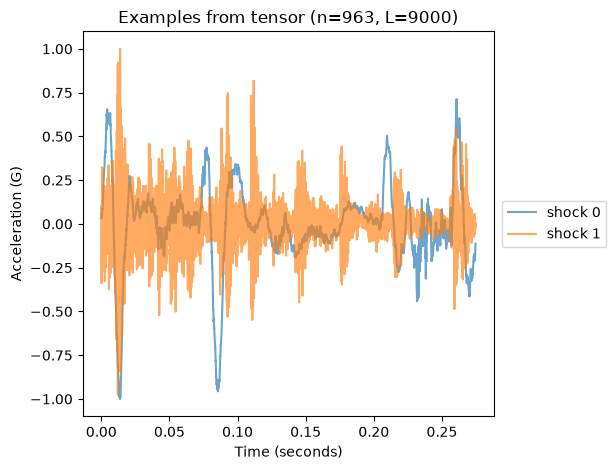

In [3]:
plot_shock_examples(x_a_torch, sample_rate=fs_a, k=2, alpha=0.66)

Explore Dataset C

In [4]:
data_c = load_dataset("C", verbose=True)
fs_c = data_c["sample_rate"].item()  # Sample rate
x_c = data_c["ts"]
x_c_torch = torch.from_numpy(x_c)      # Cast to Torch tensor

Saved archive to C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\.archives\dataset-c-npz-v1.0.0.zip
Extracted dataset to C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\Dataset_C.npz

=== Dataset C ===
path:         C:\Users\351718\Documents\ML-Shock-Time-Series-Synthesis\Datasets\Dataset_C.npz
dataset name: C
ts shape:     (815, 9000)
ts max:       0.3228461421070211
t units:      seconds
data units:   G
t start:      0.0
t end:        0.274627685546875
t count:      9000
sample rate:  32768


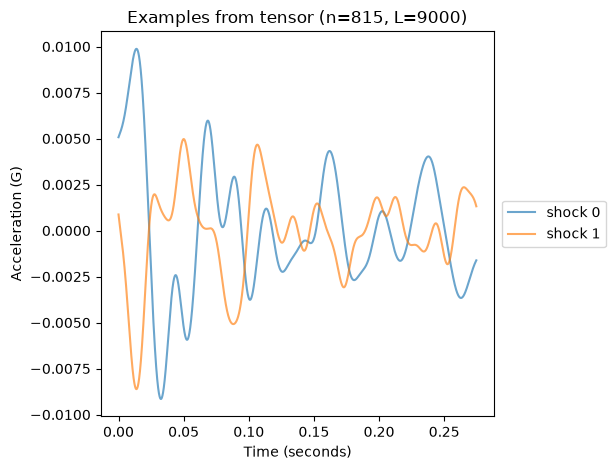

In [5]:
plot_shock_examples(x_c_torch, sample_rate=fs_c, k=2, alpha=0.66)

### Calculate SRS from Dataset A

- Pick compute device: use CUDA if available, else CPU.
- Create two samplers over 10–4096 Hz: `random` (linear-uniform) and `log` (log-uniform / denser at low Hz).
- Set `n_f = 200` to draw 200 natural frequencies for SRS evaluation.
- Sample `rand_freqs` and `log_freqs` (shape `(n_f,)`), then move/cast to `device` as needed.

In [6]:
# setup SRS natural Frequencies, random sampling from 10 to 4096 Hz
device = "cuda" if torch.cuda.is_available() else "cpu"
rand_freq_sampler = get_sampler('random', f_low=10, f_high=4096)  # What time of frequency sampling logspace, uniform, etc..,
log_freq_sampler = get_sampler('log'    , f_low=10, f_high=4096)  # What time of frequency sampling logspace, uniform, etc..,

n_f = 200 # 200 natural frequencies
rand_freqs = rand_freq_sampler(1, n_f)  # (1, n_f)  Sample frequencies
log_freqs  = log_freq_sampler(1, n_f)   # (1, n_f)  Sample frequencies

Instantiate Torch SRS 

In [7]:
srs_fn = TorchSRS(device, sample_rate=fs_a, pad_scale=3)  # Instantiate the SRS class with the sample rate

Explore SRS calculation using randomly sampled (linear-uniform) natural frequencies for SRS evaluation using dataset A

Calculating SRS: 100%|##########| 31.0/31.0 [00:01<00:00, 25.8batch/s]


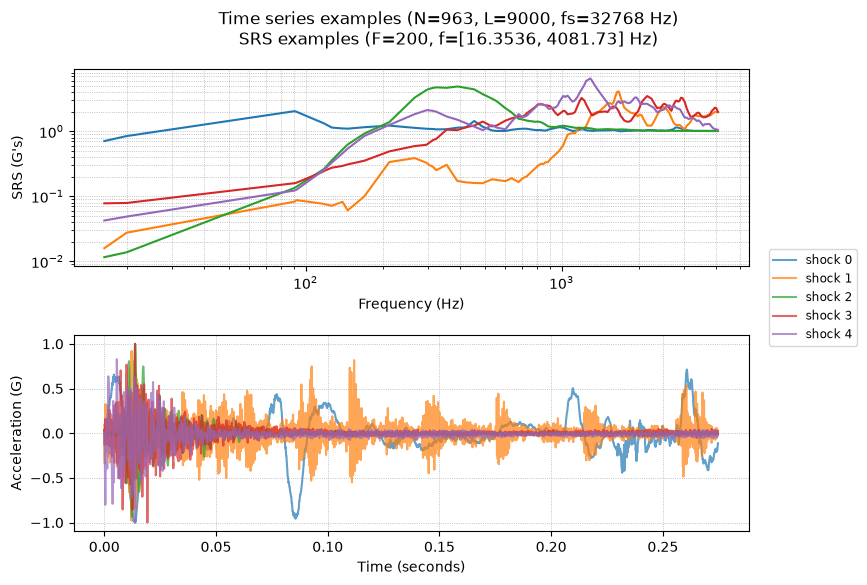

In [8]:
y_a_srs = srs_fn.batch(x_a_torch, rand_freqs, batch_size=32, max=True, progress=True) # Batch Compute the SRS for the entire dataset A and show progress bar
plot_shock_and_srs_examples(x_a_torch, y_a_srs, rand_freqs, fs_a, k=5)

Explore SRS calculation using *log-uniform* natural frequencies for SRS evaluation using dataset A

Calculating SRS: 100%|##########| 31.0/31.0 [00:00<00:00, 31.3batch/s]


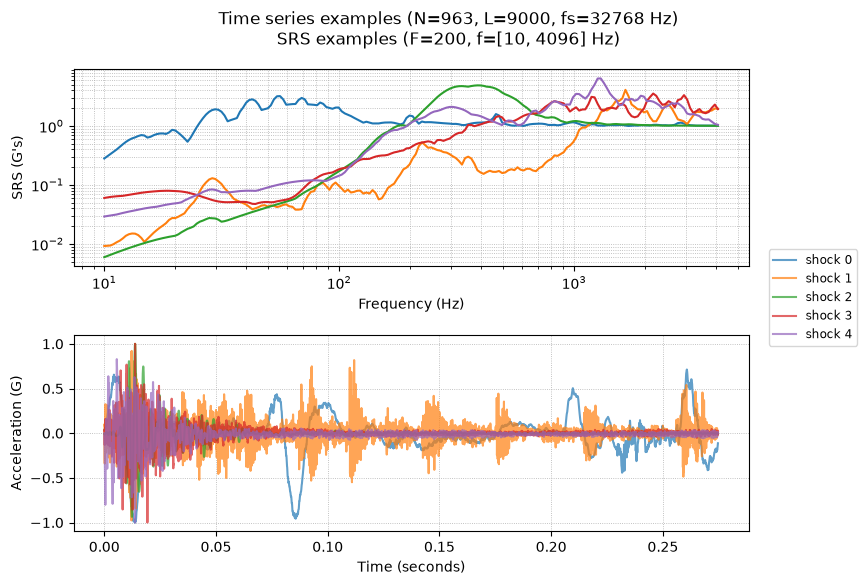

In [9]:
y_a_srs = srs_fn.batch(x_a_torch, log_freqs, batch_size=32, max=True, progress=True)  # Batch Compute the SRS for the entire dataset A and show progress bar
plot_shock_and_srs_examples(x_a_torch, y_a_srs, log_freqs, fs_a, k=5)